# Performance Analytics

## 1. Data Loading
## 2. Daily Return Calculation
## 3. CAGR Analysis
## 4. Sharpe Ratio
## 5. Sortino Ratio
## 6. Alpha & Beta
## 7. Maximum Drawdown
## 8. Fund Scorecard
## 9. Benchmark Comparison
## 10. Key Findings

In [1]:
from sqlalchemy import create_engine

server = "laptop-t5cbj27g\SQLEXPRESS"
database = "Bluestock_MF"

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

print("Connected Successfully")

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Admin\AppData\Local\Temp\ipykernel_11856\4091406864.py:3: SyntaxWarning: invalid escape sequence '\S'
  server = "laptop-t5cbj27g\SQLEXPRESS"


Connected Successfully


In [2]:
import pandas as pd
nav = pd.read_sql(
    """
    SELECT *
    FROM fact_nav
    """,
    engine
)

benchmark = pd.read_sql(
    """
    SELECT *
    FROM fact_benchmark
    """,
    engine
)

fund_master = pd.read_sql(
    """
    SELECT *
    FROM dim_fund
    """,
    engine
)

C:\ProgramData\anaconda3\Lib\site-packages\pandas\io\sql.py:1636: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [3]:
nav = nav.sort_values(
    ['amfi_code','nav_date']
)
print(nav)

       nav_id  amfi_code    nav_date       nav
5750     5751     100016  2022-01-03  520.4608
5751     5752     100016  2022-01-04  515.0971
5752     5753     100016  2022-01-05  521.7239
5753     5754     100016  2022-01-06  515.7880
5754     5755     100016  2022-01-07  515.1639
...       ...        ...         ...       ...
45995   45996     149324  2026-05-25  292.4810
45996   45997     149324  2026-05-26  291.2707
45997   45998     149324  2026-05-27  288.8007
45998   45999     149324  2026-05-28  280.6873
45999   46000     149324  2026-05-29  279.7511

[46000 rows x 4 columns]


In [4]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)
print(nav["daily_return"])

5750          NaN
5751    -0.010306
5752     0.012865
5753    -0.011377
5754    -0.001210
           ...   
45995    0.012106
45996   -0.004138
45997   -0.008480
45998   -0.028093
45999   -0.003335
Name: daily_return, Length: 46000, dtype: float64


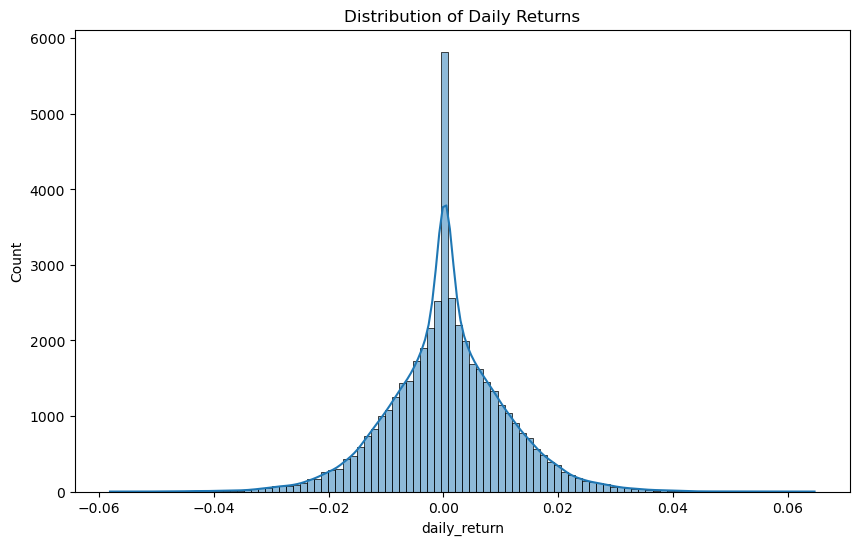

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=100,
    kde=True
)

plt.title(
    "Distribution of Daily Returns"
)

plt.show()

In [6]:
def calculate_cagr(start_nav,
                   end_nav,
                   years):

    return (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    ) * 100

In [7]:
cagr_table = []

for fund in nav['amfi_code'].unique():

    df = nav[
        nav['amfi_code']==fund
    ].sort_values('nav_date')

    start_nav = df.iloc[0]['nav']
    end_nav = df.iloc[-1]['nav']

    years = (
        (df['nav_date'].max()
         -
         df['nav_date'].min())
        .days
    ) / 365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_table.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_table,
    columns=[
        'amfi_code',
        'cagr_pct'
    ]
)
print(cagr_df)

    amfi_code   cagr_pct
0      100016   2.635246
1      100025   4.455091
2      100033  30.099704
3      101206  23.520489
4      101207   7.933121
5      101208   6.504430
6      102885  18.218826
7      102886   1.170939
8      102887  16.828673
9      118632  24.031196
10     118633  16.262218
11     118634  16.361396
12     118635  15.945481
13     118636   5.313155
14     119092   6.363495
15     119093   7.891944
16     119094  28.192608
17     119095   1.520455
18     119120   5.885271
19     119551  25.784921
20     119552  21.508022
21     119598  32.398084
22     119599   2.053064
23     120503  18.771330
24     120504  23.277448
25     120505  32.801599
26     120506  17.072228
27     120507   7.232411
28     120841  13.522349
29     120842   6.696806
30     120843  30.883326
31     120844   6.910380
32     125497  19.003613
33     125498  11.293660
34     148567  30.949920
35     148568  22.499840
36     148569  31.924486
37     149322  13.383521
38     149323  29.558105


In [8]:
RF = 0.065

In [9]:
annual_return = (
    nav.groupby('amfi_code')
       ['daily_return']
       .mean()
       * 252
)

In [10]:
import numpy as np
annual_vol = (
    nav.groupby('amfi_code')
       ['daily_return']
       .std()
       * np.sqrt(252)
)
print(annual_vol)

amfi_code
100016    0.145481
100025    0.039052
100033    0.189367
101206    0.145682
101207    0.257973
101208    0.005064
102885    0.128366
102886    0.181346
102887    0.157584
118632    0.141484
118633    0.139972
118634    0.252415
118635    0.129832
118636    0.039855
119092    0.139507
119093    0.139833
119094    0.194071
119095    0.250666
119120    0.039671
119551    0.137414
119552    0.139394
119598    0.251406
119599    0.249501
120503    0.138844
120504    0.143638
120505    0.192909
120506    0.152305
120507    0.004939
120841    0.134638
120842    0.178947
120843    0.158870
120844    0.005133
125497    0.146689
125498    0.183524
148567    0.141937
148568    0.154291
148569    0.176740
149322    0.143539
149323    0.177462
149324    0.248402
Name: daily_return, dtype: float64


In [11]:
sharpe = (
    annual_return - RF
) / annual_vol

In [12]:
sharpe_df = sharpe.reset_index()

sharpe_df.columns = [
    'amfi_code',
    'sharpe_ratio'
]
print(sharpe_df)

    amfi_code  sharpe_ratio
0      100016     -0.201517
1      100025     -0.567095
2      100033      1.093699
3      101206      1.027213
4      101207      0.162661
5      101208     -0.815567
6      102885      0.817099
7      102886     -0.205832
8      102887      0.619518
9      118632      1.081659
10     118633      0.645207
11     118634      0.448434
12     118635      0.664857
13     118636     -0.356630
14     119092      0.030785
15     119093      0.129614
16     119094      0.998231
17     119095     -0.075974
18     119120     -0.226575
19     119551      1.208267
20     119552      0.953279
21     119598      0.945308
22     119599     -0.057187
23     120503      0.797973
24     120504      1.026524
25     120505      1.180101
26     120506      0.648879
27     120507      0.495723
28     120841      0.494273
29     120842      0.076000
30     120843      1.306744
31     120844     -0.088747
32     125497      0.775790
33     125498      0.300612
34     148567      1

In [13]:
downside = nav[
    nav['daily_return'] < 0
]

In [14]:
downside_std = (
    downside.groupby('amfi_code')
            ['daily_return']
            .std()
            * np.sqrt(252)
)

In [15]:
sortino = (
    annual_return - RF
) / downside_std
print(sortino)

amfi_code
100016   -0.351047
100025   -0.941821
100033    1.829134
101206    1.799563
101207    0.276644
101208   -1.681038
102885    1.435742
102886   -0.347222
102887    1.088755
118632    1.850133
118633    1.154476
118634    0.746015
118635    1.137977
118636   -0.613525
119092    0.052574
119093    0.221087
119094    1.703797
119095   -0.128186
119120   -0.376767
119551    2.140267
119552    1.609776
119598    1.675317
119599   -0.094387
120503    1.337943
120504    1.805294
120505    2.029353
120506    1.095895
120507    1.052124
120841    0.862574
120842    0.124693
120843    2.364320
120844   -0.187723
125497    1.330651
125498    0.508813
148567    2.385644
148568    1.632741
148569    2.146914
149322    0.762129
149323    1.875101
149324    1.619793
Name: daily_return, dtype: float64


In [16]:
nifty100 = benchmark[
    benchmark['index_name']
    == 'NIFTY100'
]

In [17]:
nifty100 = nifty100.sort_values(
    'benchmark_date'
)

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

In [18]:
from scipy.stats import linregress

In [19]:
alpha_beta = []

for fund in nav['amfi_code'].unique():

    fund_df = nav[
        nav['amfi_code']==fund
    ][['nav_date',
       'daily_return']]

    merged = fund_df.merge(
        nifty100[
            ['benchmark_date',
             'benchmark_return']
        ],
        left_on='nav_date',
        right_on='benchmark_date'
    )

    merged = merged.dropna()

    slope, intercept, r, p, stderr = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    alpha_beta.append([
        fund,
        intercept*252,
        slope
    ])

In [20]:
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)
print(alpha_beta_df)

    amfi_code     alpha      beta
0      100016  0.037476 -0.058268
1      100025  0.042818  0.001158
2      100033  0.271954  0.005104
3      101206  0.213998  0.021086
4      101207  0.108971 -0.065289
5      101208  0.060861  0.000267
6      102885  0.170488 -0.019487
7      102886  0.028969 -0.042125
8      102887  0.162113  0.016683
9      118632  0.218294 -0.008354
10     118633  0.156438 -0.036639
11     118634  0.175007  0.103497
12     118635  0.151364 -0.001434
13     118636  0.050748  0.001257
14     119092  0.068995  0.009731
15     119093  0.082328  0.025883
16     119094  0.260767 -0.066265
17     119095  0.048016 -0.066951
18     119120  0.056209 -0.006414
19     119551  0.232010 -0.031751
20     119552  0.198686 -0.026159
21     119598  0.303370 -0.023196
22     119599  0.048824  0.062002
23     120503  0.177033 -0.040269
24     120504  0.211948  0.016232
25     120505  0.292636  0.000549
26     120506  0.162539  0.041896
27     120507  0.067462 -0.000444
28     120841 

In [21]:
def max_drawdown(series):

    running_max = series.cummax()

    drawdown = (
        series/running_max
        - 1
    )

    return drawdown.min()

In [22]:
dd_results = []

for fund in nav['amfi_code'].unique():

    mdd = max_drawdown(
        nav[
            nav['amfi_code']==fund
        ]['nav']
    )

    dd_results.append(
        [fund,mdd]
    )
drawdown_df = pd.DataFrame(
    dd_results,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)
print(drawdown_df)

    amfi_code  max_drawdown
0      100016     -0.247344
1      100025     -0.043083
2      100033     -0.162172
3      101206     -0.112916
4      101207     -0.354469
5      101208     -0.001622
6      102885     -0.108599
7      102886     -0.280011
8      102887     -0.215398
9      118632     -0.174141
10     118633     -0.186297
11     118634     -0.233449
12     118635     -0.116506
13     118636     -0.083164
14     119092     -0.144016
15     119093     -0.217514
16     119094     -0.209609
17     119095     -0.516778
18     119120     -0.043287
19     119551     -0.150124
20     119552     -0.118035
21     119598     -0.287060
22     119599     -0.525742
23     120503     -0.138979
24     120504     -0.125883
25     120505     -0.181885
26     120506     -0.198257
27     120507     -0.000977
28     120841     -0.175736
29     120842     -0.240035
30     120843     -0.129740
31     120844     -0.001163
32     125497     -0.152000
33     125498     -0.211173
34     148567     -0

In [26]:
scorecard = (
    cagr_df
    .merge(
        sharpe_df,
        on='amfi_code',
        how='inner'
    )
    .merge(
        alpha_beta_df,
        on='amfi_code',
        how='inner'
    )
    .merge(
        drawdown_df,
        on='amfi_code',
        how='inner'
    )
    .merge(
        fund_master[
            [
                'amfi_code',
                'expense_ratio_pct',
                'scheme_name'
            ]
        ],
        on='amfi_code',
        how='inner'
    )
)

In [27]:
scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,scheme_name
0,100016,2.635246,-0.201517,0.037476,-0.058268,-0.247344,1.55,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,4.455091,-0.567095,0.042818,0.001158,-0.043083,0.56,HDFC Short Term Debt Fund - Regular - Growth
2,100033,30.099704,1.093699,0.271954,0.005104,-0.162172,1.38,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,23.520489,1.027213,0.213998,0.021086,-0.112916,1.60,ABSL Frontline Equity Fund - Regular - Growth
4,101207,7.933121,0.162661,0.108971,-0.065289,-0.354469,1.53,ABSL Small Cap Fund - Regular - Growth


In [28]:
print("CAGR")
print(cagr_df.head())
print(cagr_df.columns)

print("\nSHARPE")
print(sharpe_df.head())
print(sharpe_df.columns)

print("\nALPHA BETA")
print(alpha_beta_df.head())
print(alpha_beta_df.columns)

print("\nDRAWDOWN")
print(drawdown_df.head())
print(drawdown_df.columns)

CAGR
   amfi_code   cagr_pct
0     100016   2.635246
1     100025   4.455091
2     100033  30.099704
3     101206  23.520489
4     101207   7.933121
Index(['amfi_code', 'cagr_pct'], dtype='object')

SHARPE
   amfi_code  sharpe_ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661
Index(['amfi_code', 'sharpe_ratio'], dtype='object')

ALPHA BETA
   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289
Index(['amfi_code', 'alpha', 'beta'], dtype='object')

DRAWDOWN
   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469
Index(['amfi_code', 'max_drawdown'], dtype='object')


In [30]:
scorecard['return_rank'] = scorecard['cagr_pct'].rank(ascending=False)

scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=False)

scorecard['alpha_rank'] = scorecard['alpha'].rank(ascending=False)

scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank(ascending=True)

scorecard['drawdown_rank'] = scorecard['max_drawdown'].rank(ascending=False)

In [32]:
scorecard['raw_score'] = (
      0.30 * scorecard['return_rank']
    + 0.25 * scorecard['sharpe_rank']
    + 0.20 * scorecard['alpha_rank']
    + 0.15 * scorecard['expense_rank']
    + 0.10 * scorecard['drawdown_rank']
)

In [36]:
scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
)
print(scorecard)

    amfi_code   cagr_pct  sharpe_ratio     alpha      beta  max_drawdown  \
25     120505  32.801599      1.180101  0.292636  0.000549     -0.181885   
34     148567  30.949920      1.448291  0.269838  0.023684     -0.112657   
30     120843  30.883326      1.306744  0.273305 -0.022830     -0.129740   
2      100033  30.099704      1.093699  0.271954  0.005104     -0.162172   
36     148569  31.924486      1.234930  0.282704  0.018134     -0.163967   
21     119598  32.398084      0.945308  0.303370 -0.023196     -0.287060   
24     120504  23.277448      1.026524  0.211948  0.016232     -0.125883   
20     119552  21.508022      0.953279  0.198686 -0.026159     -0.118035   
39     149324  32.262108      0.949796  0.300579  0.011455     -0.311719   
19     119551  25.784921      1.208267  0.232010 -0.031751     -0.150124   
16     119094  28.192608      0.998231  0.260767 -0.066265     -0.209609   
38     149323  29.558105      1.132122  0.265986 -0.002523     -0.172481   
9      11863

In [37]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [38]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

In [43]:
top5_funds = (
    scorecard
    .head(5)
    ['amfi_code']
    .tolist()
)

top5_funds

[100016, 100025, 100033, 101206, 101207]

In [44]:
top5_nav = nav[
    nav['amfi_code'].isin(top5_funds)
].copy()

In [45]:
top5_nav = top5_nav.merge(
    fund_master[
        ['amfi_code','scheme_name']
    ],
    on='amfi_code'
)

In [46]:
top5_nav['normalized_nav'] = (
    top5_nav.groupby('amfi_code')['nav']
    .transform(
        lambda x: x / x.iloc[0] * 100
    )
)

In [47]:
benchmarks = benchmark[
    benchmark['index_name'].isin(
        ['NIFTY50','NIFTY100']
    )
].copy()

In [48]:
benchmarks['normalized_value'] = (
    benchmarks.groupby('index_name')['close_value']
    .transform(
        lambda x: x / x.iloc[0] * 100
    )
)

In [49]:
benchmark_plot = benchmarks[
    [
        'benchmark_date',
        'index_name',
        'normalized_value'
    ]
].copy()

benchmark_plot.columns = [
    'date',
    'name',
    'value'
]

In [50]:
fund_plot = top5_nav[
    [
        'nav_date',
        'scheme_name',
        'normalized_nav'
    ]
].copy()

fund_plot.columns = [
    'date',
    'name',
    'value'
]

In [51]:
comparison_df = pd.concat(
    [
        fund_plot,
        benchmark_plot
    ]
)

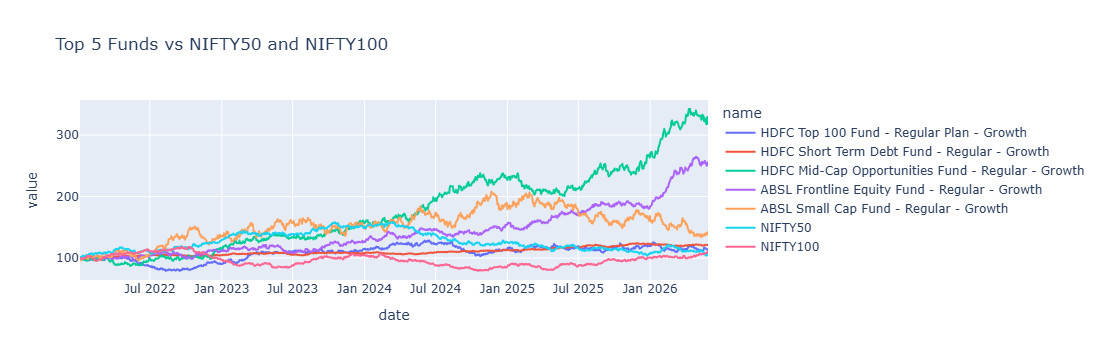

In [52]:
import plotly.express as px

fig = px.line(
    comparison_df,
    x='date',
    y='value',
    color='name',
    title='Top 5 Funds vs NIFTY50 and NIFTY100'
)

fig.show()

In [53]:
fig.write_image(
    "benchmark_comparison.png",
    width=1400,
    height=800
)